<a href="https://colab.research.google.com/github/Herrera1022/Modelo_afluencia_metro_pruebas/blob/main/mlp_model_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Herrera1022/Modelo_afluencia_metro_pruebas.git
import os
os.chdir("Modelo_afluencia_metro_pruebas")
!ls

Cloning into 'Modelo_afluencia_metro_pruebas'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 125 (delta 68), reused 64 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (125/125), 13.90 MiB | 5.93 MiB/s, done.
Resolving deltas: 100% (68/68), done.
 afluencia_metro_2024_transformado.csv	'Paper primera entrega.pdf'
 Afluencia_Metro_2024.xlsx		 README.md
 Exploracion_inicial.ipynb		 regresion.ipynb
 gradient_boosting_model.ipynb		 splits
 knn_model.ipynb


# Modelo 4: MLP (Multi-Layer Perceptron Regressor)

##Librerias


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

Importación de los splits

In [3]:
X_train      = pd.read_csv("./splits/X_train.csv")
y_train      = pd.read_csv("./splits/y_train.csv")

X_validation = pd.read_csv("./splits/X_validation.csv")
y_validation = pd.read_csv("./splits/y_validation.csv")

X_test       = pd.read_csv("./splits/X_test.csv")
y_test       = pd.read_csv("./splits/y_test.csv")

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_validation.shape}")
print(f"Test:       {X_test.shape}")

Train:      (59899, 22)
Validation: (6947, 22)
Test:       (13611, 22)


## Entrenamiento

### Selección de parámetros

Para el modelo MLP se deben definir tres hiperparámetros principales: hidden_layer_sizes, que define la arquitectura de capas ocultas y neuronas por capa; activation, que determina la función de activación de las neuronas; y learning_rate_init, que controla la velocidad de aprendizaje inicial del optimizador.

Inicialmente, se establecerán los diferentes valores que serán evaluados para cada hiperparámetro.

In [8]:
arquitecturas = [
    (50,),
    (100,),
    (100, 50),
    (100, 100),
    (200, 100),
    (200, 100, 50),
]

activation_options    = ["relu"]
learning_rate_options = [0.001, 0.01]

La metodología consistirá en iterar sobre las distintas combinaciones de hiperparámetros, evaluando en cada caso el desempeño del modelo mediante MAE (principal), RMSE (complementaria), R² (descriptiva) y WMAPE (relativa) en entrenamiento y validación.

Además, se definió un criterio de parada para las iteraciones de cada valor de learning_rate_init: si el modelo no presenta mejora en su MAE de validación durante tres iteraciones consecutivas, el proceso se detendrá y el mejor resultado obtenido hasta ese momento será considerado como el modelo óptimo.

In [9]:
resultados = []

best_model  = None
best_params = None
best_mae    = float("inf")

# ============================================
# BÚSQUEDA DE HIPERPARÁMETROS
# ============================================

for activation in activation_options:
    for lr in learning_rate_options:

        print(f"\nProbando activation='{activation}' | learning_rate_init={lr}")

        mae_anterior = float("inf")
        no_mejora    = 0

        for arquitectura in arquitecturas:

            # Modelo
            model = MLPRegressor(
                hidden_layer_sizes = arquitectura,
                activation         = activation,
                learning_rate_init = lr,
                max_iter           = 2000,
                random_state       = 42
            )

            # Entrenamiento
            model.fit(X_train, y_train.values.ravel())

            # Predicciones
            y_pred_train = model.predict(X_train)
            y_pred_val   = model.predict(X_validation)

            # ============================================
            # MÉTRICAS TRAIN
            # ============================================

            rmse_train  = np.sqrt(mean_squared_error(y_train, y_pred_train))
            mae_train   = mean_absolute_error(y_train, y_pred_train)
            r2_train    = r2_score(y_train, y_pred_train)
            wmape_train = np.sum(np.abs(y_train.values.ravel() - y_pred_train)) / np.sum(y_train.values.ravel()) * 100

            # ============================================
            # MÉTRICAS VALIDATION
            # ============================================

            rmse_val  = np.sqrt(mean_squared_error(y_validation, y_pred_val))
            mae_val   = mean_absolute_error(y_validation, y_pred_val)
            r2_val    = r2_score(y_validation, y_pred_val)
            wmape_val = np.sum(np.abs(y_validation.values.ravel() - y_pred_val)) / np.sum(y_validation.values.ravel()) * 100

            # ============================================
            # GUARDAR RESULTADOS
            # ============================================

            resultados.append({
                "arquitectura":       str(arquitectura),
                "activation":         activation,
                "learning_rate_init": lr,

                "RMSE_train":      rmse_train,
                "RMSE_validation": rmse_val,

                "MAE_train":      mae_train,
                "MAE_validation": mae_val,

                "R2_train":      r2_train,
                "R2_validation": r2_val,

                "WMAPE_train":      wmape_train,
                "WMAPE_validation": wmape_val
            })

            print(
                f"  {str(arquitectura):<18} | "
                f"MAE Val={mae_val:.2f} | "
                f"RMSE Val={rmse_val:.2f} | "
                f"R2 Val={r2_val:.4f} | "
                f"WMAPE Val={wmape_val:.2f}%"
            )

            # ============================================
            # EARLY STOPPING
            # ============================================

            if mae_val < mae_anterior:
                no_mejora = 0
            else:
                no_mejora += 1

            # ============================================
            # MEJOR MODELO GLOBAL
            # ============================================

            if mae_val < best_mae:
                best_mae    = mae_val
                best_params = {
                    "arquitectura":       arquitectura,
                    "activation":         activation,
                    "learning_rate_init": lr
                }
                best_model = model

            # ============================================
            # DETENER SI NO MEJORA
            # ============================================

            if no_mejora >= 3:
                print(
                    f"  Deteniendo para activation='{activation}' "
                    f"lr={lr} por falta de mejora."
                )
                break

            mae_anterior = mae_val


Probando activation='relu' | learning_rate_init=0.001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


  (50,)              | MAE Val=441.89 | RMSE Val=1374.19 | R2 Val=0.9823 | WMAPE Val=10.28%


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


  (100,)             | MAE Val=439.47 | RMSE Val=1299.35 | R2 Val=0.9842 | WMAPE Val=10.23%
  (100, 50)          | MAE Val=272.91 | RMSE Val=1028.13 | R2 Val=0.9901 | WMAPE Val=6.35%
  (100, 100)         | MAE Val=260.62 | RMSE Val=1009.59 | R2 Val=0.9905 | WMAPE Val=6.06%
  (200, 100)         | MAE Val=261.77 | RMSE Val=1003.86 | R2 Val=0.9906 | WMAPE Val=6.09%
  (200, 100, 50)     | MAE Val=263.65 | RMSE Val=1059.41 | R2 Val=0.9895 | WMAPE Val=6.13%

Probando activation='relu' | learning_rate_init=0.01
  (50,)              | MAE Val=363.88 | RMSE Val=1139.20 | R2 Val=0.9878 | WMAPE Val=8.47%
  (100,)             | MAE Val=338.39 | RMSE Val=1105.97 | R2 Val=0.9885 | WMAPE Val=7.87%
  (100, 50)          | MAE Val=273.29 | RMSE Val=1009.46 | R2 Val=0.9905 | WMAPE Val=6.36%
  (100, 100)         | MAE Val=266.12 | RMSE Val=1050.16 | R2 Val=0.9897 | WMAPE Val=6.19%
  (200, 100)         | MAE Val=266.27 | RMSE Val=1131.52 | R2 Val=0.9880 | WMAPE Val=6.20%
  (200, 100, 50)     | MAE Val=303.

### Resultados

In [10]:
resultados_df = pd.DataFrame(resultados)

print("\n==============================")
print("MEJORES PARÁMETROS")
print("==============================")
print(best_params)
print(f"Mejor MAE Validation: {best_mae:.2f}")


MEJORES PARÁMETROS
{'arquitectura': (100, 100), 'activation': 'relu', 'learning_rate_init': 0.001}
Mejor MAE Validation: 260.62


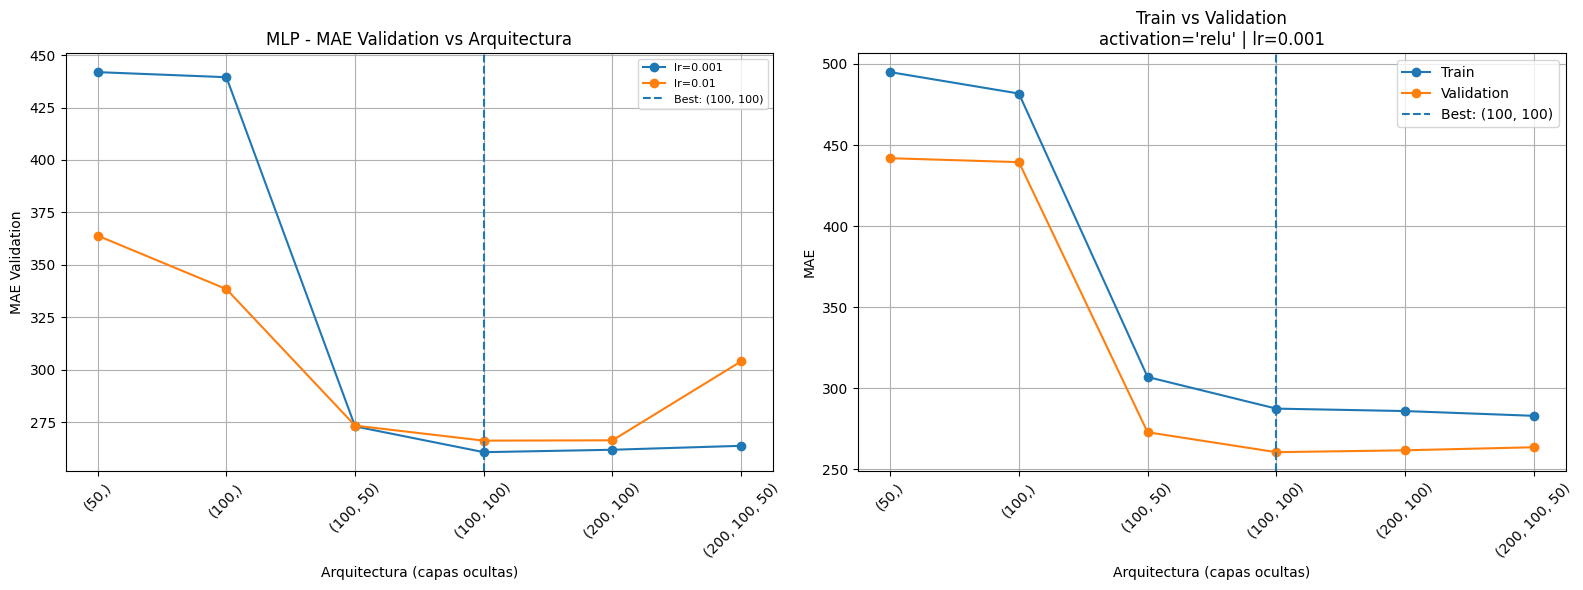

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================
# GRÁFICA 1
# MAE Validation vs arquitectura por learning_rate
# ============================================

for lr in learning_rate_options:
    subset = resultados_df[
        resultados_df["learning_rate_init"] == lr
    ]
    axes[0].plot(
        subset["arquitectura"],
        subset["MAE_validation"],
        marker="o",
        label=f"lr={lr}"
    )

axes[0].set_xlabel("Arquitectura (capas ocultas)")
axes[0].set_ylabel("MAE Validation")
axes[0].set_title("MLP - MAE Validation vs Arquitectura")
axes[0].axvline(
    str(best_params["arquitectura"]),
    linestyle="--",
    label=f"Best: {best_params['arquitectura']}"
)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True)

# ============================================
# GRÁFICA 2
# Train vs Validation para el mejor learning_rate
# ============================================

subset_best = resultados_df[
    resultados_df["learning_rate_init"] == best_params["learning_rate_init"]
]

axes[1].plot(
    subset_best["arquitectura"],
    subset_best["MAE_train"],
    marker="o",
    label="Train"
)
axes[1].plot(
    subset_best["arquitectura"],
    subset_best["MAE_validation"],
    marker="o",
    label="Validation"
)
axes[1].set_xlabel("Arquitectura (capas ocultas)")
axes[1].set_ylabel("MAE")
axes[1].set_title(
    f"Train vs Validation\n"
    f"activation='relu' | lr={best_params['learning_rate_init']}"
)
axes[1].axvline(
    str(best_params["arquitectura"]),
    linestyle="--",
    label=f"Best: {best_params['arquitectura']}"
)
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True)

plt.tight_layout()
plt.show()

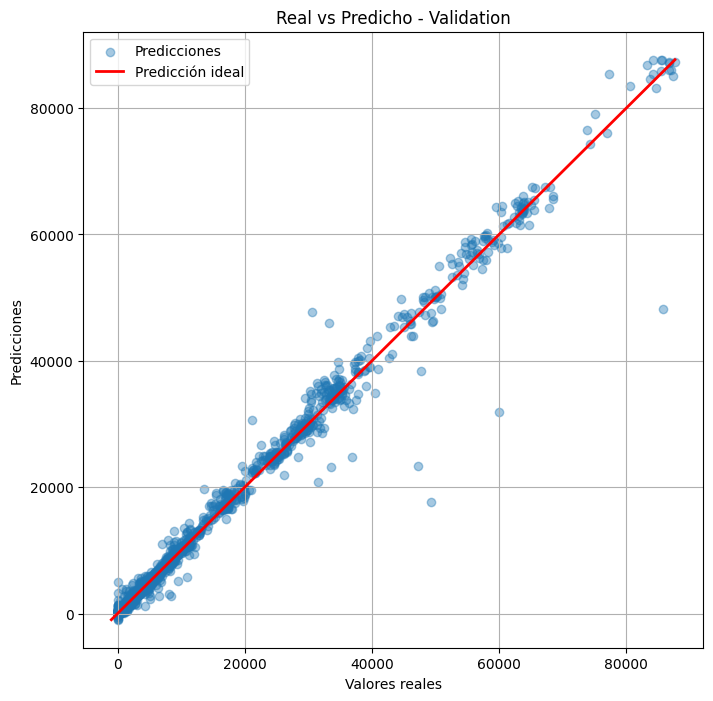

In [12]:
y_pred_val = best_model.predict(X_validation)

y_true = y_validation.values.ravel()
y_pred = y_pred_val.ravel()

# ============================================
# GRÁFICA REAL VS PREDICHO
# ============================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.4,
    label="Predicciones"
)

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    label="Predicción ideal"
)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho - Validation")
plt.legend()
plt.grid(True)
plt.show()

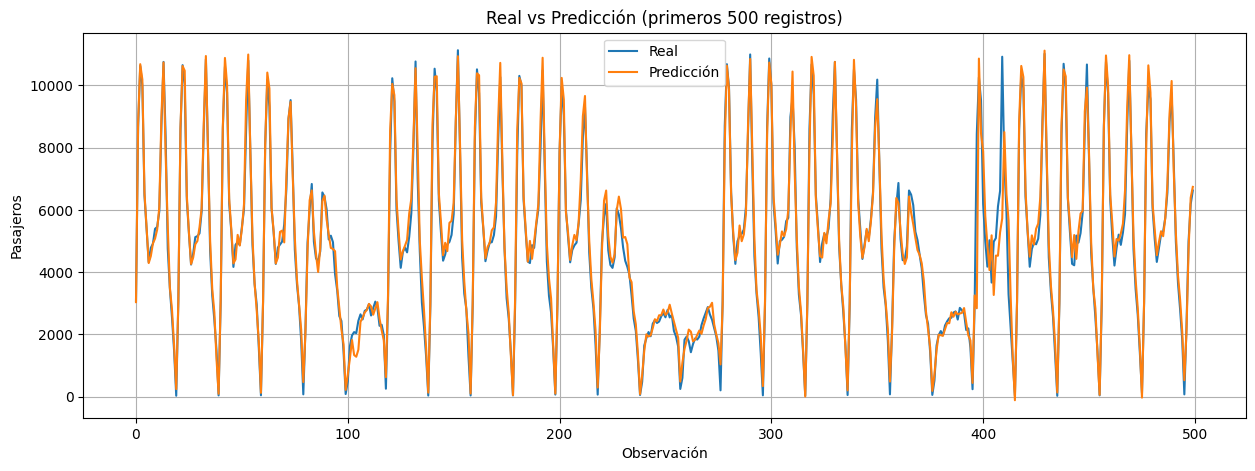

In [13]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_validation.values[:500],
    label="Real"
)

plt.plot(
    y_pred_val[:500],
    label="Predicción"
)

plt.title("Real vs Predicción (primeros 500 registros)")
plt.xlabel("Observación")
plt.ylabel("Pasajeros")
plt.legend()
plt.grid(True)
plt.show()

Guardar el modelo

In [14]:
import os
os.makedirs("./models", exist_ok=True)
joblib.dump(best_model, "./models/mlp.pkl")
print("Modelo guardado en ./models/mlp.pkl")

Modelo guardado en ./models/mlp.pkl
